# 2 Optimasation problem

We want to optimize the predictive performance of machine learning models in estimating productivity improvement for firms in the Technology industry.

In [3]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#Remove warning that are not imp
import warnings 
warnings.filterwarnings('ignore')

# 3 Data exploration 

In [5]:
#Download data
datafile = "Dataset-CB4246_23.csv"
rawdata = pd.read_csv(datafile)
rawdata.head() #Ensure data is imported

,response_id,company_id,survey_year,quarter,country,region,industry,company_size,num_employees,annual_revenue_usd_millions,...,productivity_change_percent,jobs_displaced,jobs_created,reskilled_employees,revenue_growth_percent,cost_reduction_percent,innovation_score,customer_satisfaction,survey_source,data_collection_method
0,1,COMP-00001,2023,Q1,Italy,Europe,Education,Startup,57,48.31,...,2.65,1,1,3,2.52,9.45,53,5.20,WEF Survey,API Scrape
1,2,COMP-00001,2023,Q2,Italy,Europe,Education,Startup,57,48.31,...,5.77,2,2,5,4.77,0.00,51,6.98,McKinsey Report,Phone Interview
2,3,COMP-00001,2023,Q3,Italy,Europe,Education,Startup,57,48.31,...,6.94,3,3,2,12.87,9.74,40,4.12,Internal Corporate Survey,Research Compilation
3,4,COMP-00001,2023,Q4,Italy,Europe,Education,Startup,57,48.31,...,5.32,1,1,2,8.19,0.00,51,5.72,Internal Corporate Survey,Research Compilation
4,5,COMP-00001,2024,Q1,Italy,Europe,Education,Startup,57,48.31,...,6.32,2,3,6,11.30,9.02,43,6.31,McKinsey Report,Research Compilation


In [5]:
# show information about the columns
rawdata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   response_id                  150000 non-null  int64  
 1   company_id                   150000 non-null  object 
 2   survey_year                  150000 non-null  int64  
 3   quarter                      150000 non-null  object 
 4   country                      150000 non-null  object 
 5   region                       150000 non-null  object 
 6   industry                     150000 non-null  object 
 7   company_size                 150000 non-null  object 
 8   num_employees                150000 non-null  int64  
 9   annual_revenue_usd_millions  150000 non-null  float64
 10  company_founding_year        150000 non-null  int64  
 11  company_age                  150000 non-null  int64  
 12  company_age_group            150000 non-null  object 
 13 

In [6]:
#Show industry data distribution
rawdata['industry'].value_counts()

industry
Technology       21107
Finance          20166
Healthcare       18642
Manufacturing    17501
Retail           16377
Agriculture      15570
Education        15172
Logistics        12961
Consulting       12504
Name: count, dtype: int64

## 3.1 Data cleaning

Steps taken:
1. Filter data to focus on ‘industry’ = Technology.
2. Check duplicate
3. Drop identifier columns that contain no predictive information to the problem statement
4. Determine hidden invalid unique values
5. Drop redundancy in descriptive factors
6. Drop results of AI adoption and business performance variables, since they are not decisions
7. Split into the numeric type and categorical type

In [8]:
#Filter dataset to contain data from Technological industry
#Use full dataset (all industries) for training
data = rawdata.copy()

print("Rows:", len(data))
print("Columns: ", len(data.columns))
data.columns

Rows: 150000
Columns:  43


Index(['response_id', 'company_id', 'survey_year', 'quarter', 'country',
       'region', 'industry', 'company_size', 'num_employees',
       'annual_revenue_usd_millions', 'company_founding_year', 'company_age',
       'company_age_group', 'ai_adoption_rate', 'ai_adoption_stage',
       'years_using_ai', 'ai_primary_tool', 'num_ai_tools_used', 'ai_use_case',
       'ai_projects_active', 'ai_training_hours', 'ai_budget_percentage',
       'ai_maturity_score', 'ai_failure_rate', 'ai_investment_per_employee',
       'regulatory_compliance_score', 'data_privacy_level',
       'ai_ethics_committee', 'ai_risk_management_score',
       'remote_work_percentage', 'employee_satisfaction_score',
       'task_automation_rate', 'time_saved_per_week',
       'productivity_change_percent', 'jobs_displaced', 'jobs_created',
       'reskilled_employees', 'revenue_growth_percent',
       'cost_reduction_percent', 'innovation_score', 'customer_satisfaction',
       'survey_source', 'data_collection_meth

In [9]:
# Check duplicate responses
print("Duplicate response_id:", data["response_id"].duplicated().sum())

Duplicate response_id: 0


In [10]:
#Drop identifier columns that contain no predictive information to the problem statement
data = data.drop(['response_id', 'company_id', 'survey_source', 'data_collection_method'], axis=1)

#Drop timeseries features
data = data.drop(['survey_year', 'quarter', 'company_founding_year'], axis=1)

print("Columns: ", len(data.columns))
data.columns

Columns:  36


Index(['country', 'region', 'industry', 'company_size', 'num_employees',
       'annual_revenue_usd_millions', 'company_age', 'company_age_group',
       'ai_adoption_rate', 'ai_adoption_stage', 'years_using_ai',
       'ai_primary_tool', 'num_ai_tools_used', 'ai_use_case',
       'ai_projects_active', 'ai_training_hours', 'ai_budget_percentage',
       'ai_maturity_score', 'ai_failure_rate', 'ai_investment_per_employee',
       'regulatory_compliance_score', 'data_privacy_level',
       'ai_ethics_committee', 'ai_risk_management_score',
       'remote_work_percentage', 'employee_satisfaction_score',
       'task_automation_rate', 'time_saved_per_week',
       'productivity_change_percent', 'jobs_displaced', 'jobs_created',
       'reskilled_employees', 'revenue_growth_percent',
       'cost_reduction_percent', 'innovation_score', 'customer_satisfaction'],
      dtype='object')

In [11]:
#Show unique values to determine hidden invalid unique values
for i, col in enumerate(data.columns):
    print("\nColumn:", i)
    print("Unique values:", data[col].nunique())
    print(data[col].unique()[:20])
    print(data[col].value_counts().head(10))


Column: 0
Unique values: 30
['Italy' 'UK' 'Germany' 'USA' 'Chile' 'Philippines' 'South Africa' 'India'
 'Thailand' 'Malaysia' 'Sweden' 'Spain' 'Egypt' 'Netherlands' 'Colombia'
 'Canada' 'Australia' 'Indonesia' 'Singapore' 'China']
country
France         5637
Japan          5629
South Korea    5443
Germany        5327
Chile          5190
Egypt          5125
Netherlands    5118
Philippines    5091
Poland         5086
USA            5058
Name: count, dtype: int64

Column: 1
Unique values: 6
['Europe' 'North America' 'South America' 'Asia' 'Africa' 'Oceania']
region
Asia             49727
Europe           40835
South America    19909
Africa           19787
Oceania          10002
North America     9740
Name: count, dtype: int64

Column: 2
Unique values: 9
['Education' 'Finance' 'Manufacturing' 'Healthcare' 'Agriculture'
 'Technology' 'Logistics' 'Retail' 'Consulting']
industry
Technology       21107
Finance          20166
Healthcare       18642
Manufacturing    17501
Retail           16377

In [12]:
#Drop redundancy in descriptive factors
data = data.drop(['country', 'company_age', 'ai_primary_tool', 'ai_investment_per_employee'], axis=1)

#Drop results of AI adoption and business performance variables, since they are not decisions
data = data.drop(['ai_failure_rate', 'reskilled_employees', 'revenue_growth_percent', 'annual_revenue_usd_millions',
                  'cost_reduction_percent', 'innovation_score', 'customer_satisfaction', 'jobs_displaced', 'jobs_created'], axis=1)

print("Columns: ", len(data.columns))
data.columns

Columns:  23


Index(['region', 'industry', 'company_size', 'num_employees',
       'company_age_group', 'ai_adoption_rate', 'ai_adoption_stage',
       'years_using_ai', 'num_ai_tools_used', 'ai_use_case',
       'ai_projects_active', 'ai_training_hours', 'ai_budget_percentage',
       'ai_maturity_score', 'regulatory_compliance_score',
       'data_privacy_level', 'ai_ethics_committee', 'ai_risk_management_score',
       'remote_work_percentage', 'employee_satisfaction_score',
       'task_automation_rate', 'time_saved_per_week',
       'productivity_change_percent'],
      dtype='object')

In [13]:
num_data = data.select_dtypes(include=['int64','float64'])
cat_data = data.select_dtypes(include=['object'])

print("Numerical columns:")
num_data.info()

print("\nCategorical columns:")
cat_data.info()

Numerical columns:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 15 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   num_employees                150000 non-null  int64  
 1   ai_adoption_rate             150000 non-null  float64
 2   years_using_ai               150000 non-null  int64  
 3   num_ai_tools_used            150000 non-null  int64  
 4   ai_projects_active           150000 non-null  int64  
 5   ai_training_hours            150000 non-null  float64
 6   ai_budget_percentage         150000 non-null  float64
 7   ai_maturity_score            150000 non-null  float64
 8   regulatory_compliance_score  150000 non-null  int64  
 9   ai_risk_management_score     150000 non-null  int64  
 10  remote_work_percentage       150000 non-null  float64
 11  employee_satisfaction_score  150000 non-null  float64
 12  task_automation_rate         150000 non

In [14]:
# descriptive statistics
num_data.describe()

,num_employees,ai_adoption_rate,years_using_ai,num_ai_tools_used,ai_projects_active,ai_training_hours,ai_budget_percentage,ai_maturity_score,regulatory_compliance_score,ai_risk_management_score,remote_work_percentage,employee_satisfaction_score,task_automation_rate,time_saved_per_week,productivity_change_percent
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000
mean,2342.376580,36.414726,4.931580,2.315120,6.270693,27.207475,9.509800,0.344675,70.397880,59.566500,43.191203,5.600767,19.761744,6.267406,9.266996
std,4754.424755,14.544096,2.429316,0.946826,3.500142,13.136749,3.837827,0.133820,9.406102,8.851409,14.363378,0.814567,9.222562,2.977495,5.637067
min,10.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,40.000000,40.000000,0.000000,2.100000,0.000000,0.000000,0.000000
25%,69.000000,26.430000,3.000000,2.000000,4.000000,18.070000,6.880000,0.250000,64.000000,53.000000,33.210000,5.050000,13.360000,4.180000,5.070000
50%,349.000000,36.320000,5.000000,2.000000,6.000000,27.060000,9.430000,0.341000,70.000000,59.000000,42.670000,5.600000,19.700000,6.230000,9.060000
75%,884.000000,46.200000,7.000000,3.000000,9.000000,36.130000,12.080000,0.435000,77.000000,66.000000,52.740000,6.150000,26.020000,8.290000,13.120000
max,19970.000000,100.000000,10.000000,6.000000,20.000000,80.000000,25.000000,0.904000,100.000000,98.000000,100.000000,9.200000,59.630000,19.150000,34.360000


In [15]:
# Check categorical balance
for col in cat_data.columns:
    print(cat_data[col].value_counts(normalize=True))

region
Asia             0.331513
Europe           0.272233
South America    0.132727
Africa           0.131913
Oceania          0.066680
North America    0.064933
Name: proportion, dtype: float64
industry
Technology       0.140713
Finance          0.134440
Healthcare       0.124280
Manufacturing    0.116673
Retail           0.109180
Agriculture      0.103800
Education        0.101147
Logistics        0.086407
Consulting       0.083360
Name: proportion, dtype: float64
company_size
SME           0.42578
Startup       0.37790
Enterprise    0.19632
Name: proportion, dtype: float64
company_age_group
16-30 years    0.455887
6-15 years     0.306613
30+ years      0.135020
0-5 years      0.102480
Name: proportion, dtype: float64
ai_adoption_stage
partial    0.525333
pilot      0.428780
none       0.034653
full       0.011233
Name: proportion, dtype: float64
ai_use_case
Customer Support             0.251220
HR Automation                0.201227
Marketing Automation         0.140867
Predictive M

### 3.2 Data preparation

**Numeric**
1. evaluate outliers for numeric data and handle them
2. evaluate target feature if any skewness
3. Correlation analysis (keep features with at least 50% correlation)

**Categorical**
1. Analysis the feature impact, only keep those with predictive value
2. Encode remained categorical feature

**Trianing Preperation**
1. Split features and target
2. train-test-validation split (70/15/15)
3. Scale training data and test-va data


In [17]:
#Investigate outliners
outlier_counts = {}

for col in num_data.columns:
    Q1 = num_data[col].quantile(0.25)
    Q3 = num_data[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    count = num_data[(num_data[col] < lower) | (num_data[col] > upper)].shape[0]
    outlier_counts[col] = (count/len(num_data))*100 #percentage outlier of total data

pd.Series(outlier_counts).sort_values(ascending=False)

num_employees                  18.596000
num_ai_tools_used               1.058000
employee_satisfaction_score     0.642000
remote_work_percentage          0.566667
regulatory_compliance_score     0.470667
ai_budget_percentage            0.429333
ai_maturity_score               0.388000
productivity_change_percent     0.352667
ai_training_hours               0.352000
time_saved_per_week             0.350667
task_automation_rate            0.340667
ai_adoption_rate                0.336000
ai_projects_active              0.235333
ai_risk_management_score        0.179333
years_using_ai                  0.000000
dtype: float64

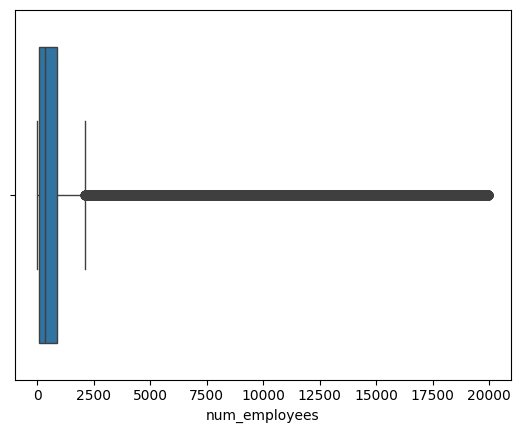

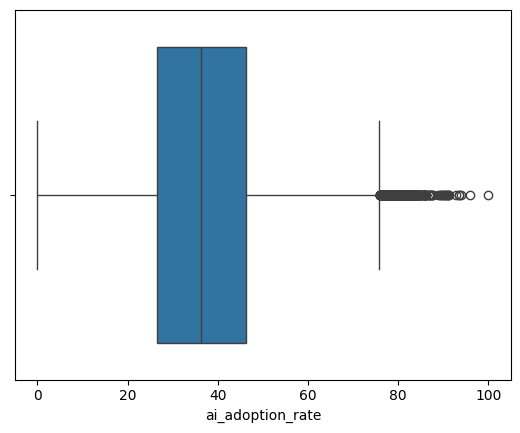

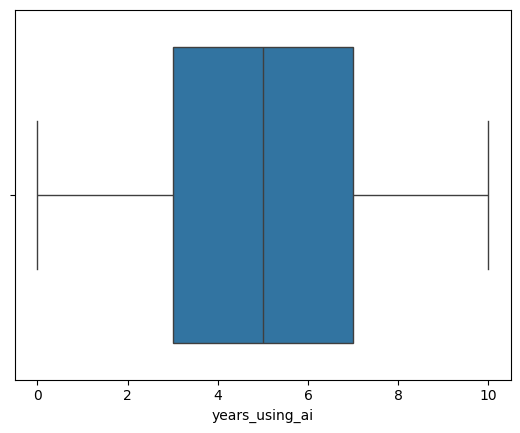

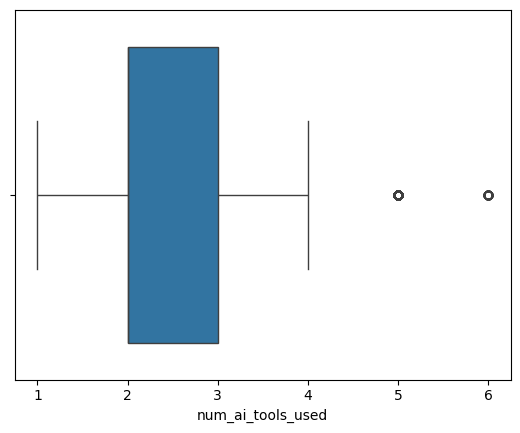

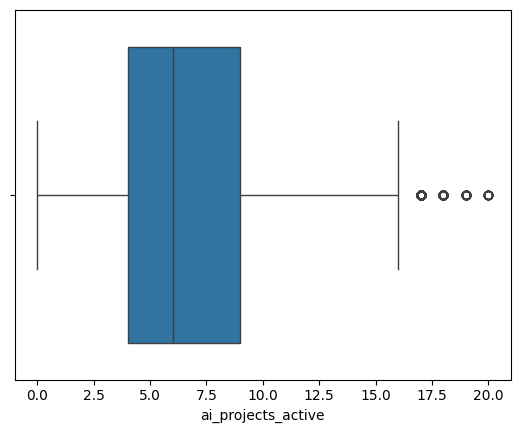

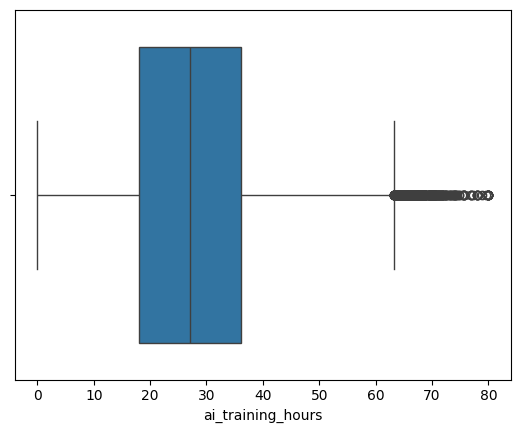

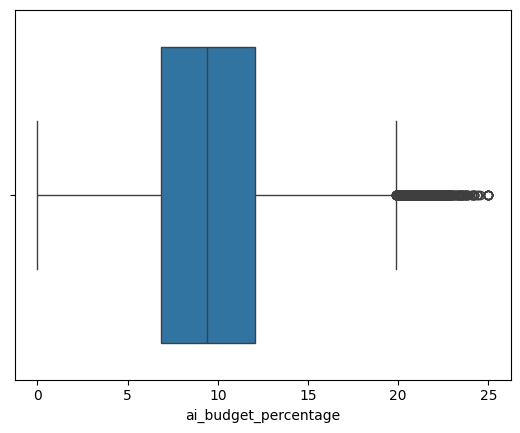

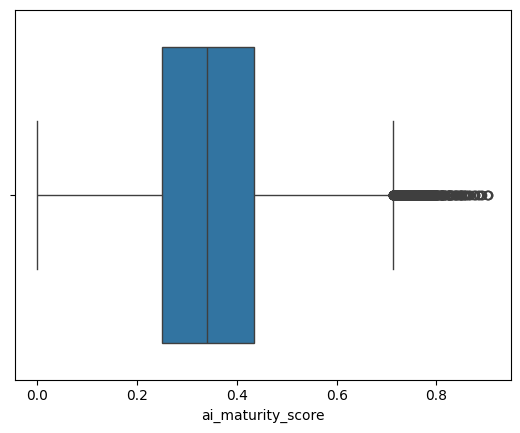

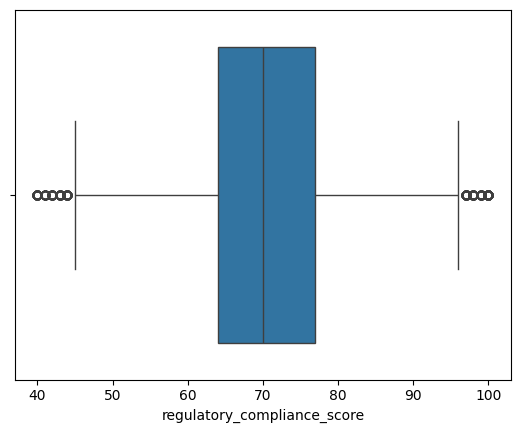

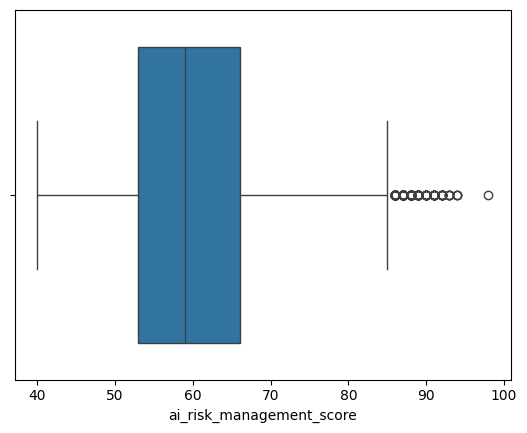

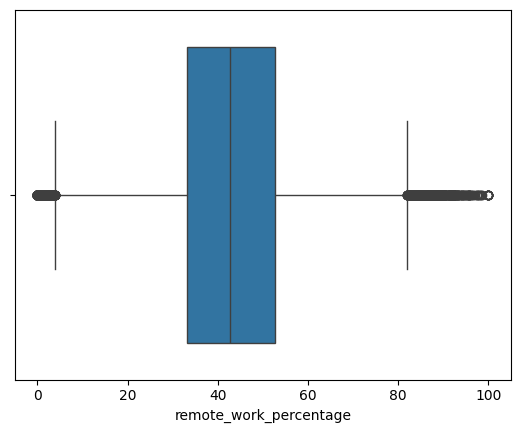

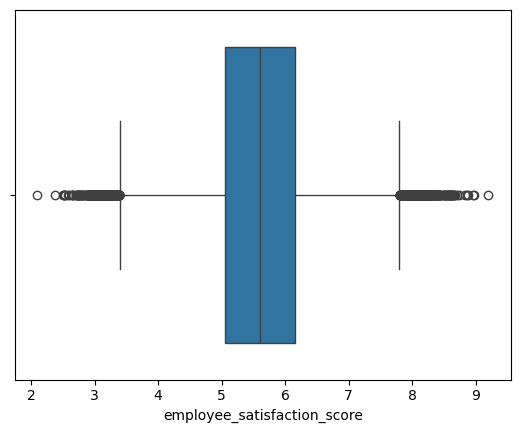

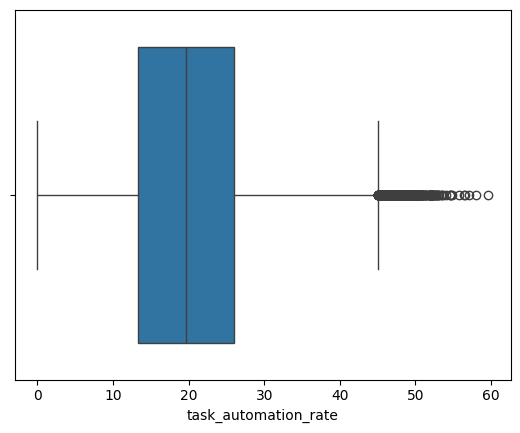

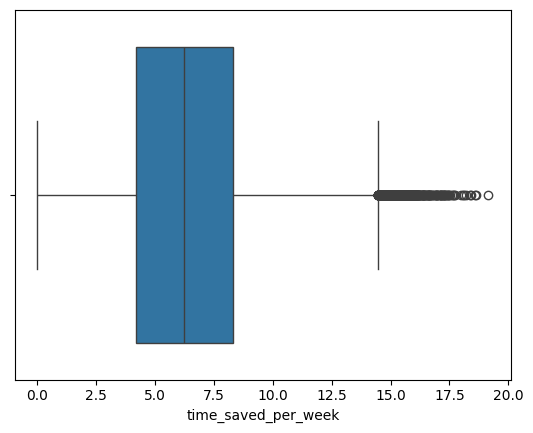

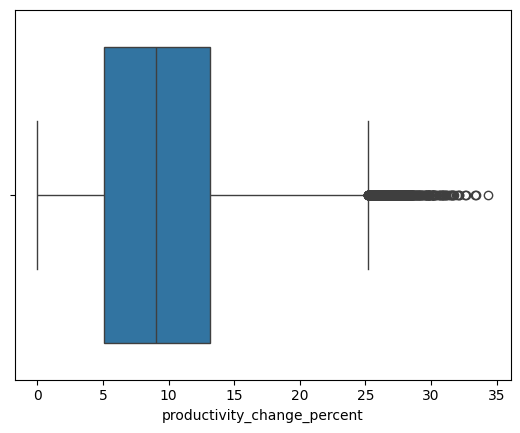

In [18]:
for col in num_data.columns:
    sns.boxplot(x=num_data[col])
    plt.show()

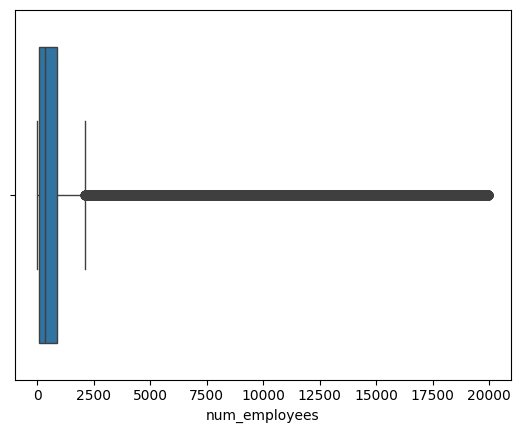

In [19]:
#investigate num_employees as large outlier count is observed. (due to company size difference)
# Show num_employees plot
sns.boxplot(x=num_data['num_employees'])
plt.show()

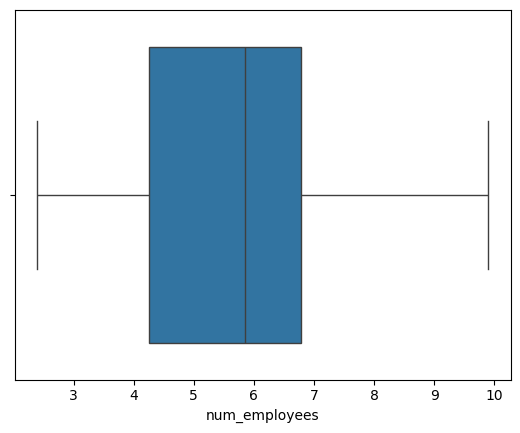

In [20]:
# Handle outlier
num_data_clean = num_data.copy()

#log transform num_employees
num_data_clean["num_employees"] = np.log1p(num_data["num_employees"])

# Show num_employees plot to check
sns.boxplot(x=num_data_clean['num_employees'])
plt.show()

In [21]:
#evaluate target feature's distribution
num_data_clean['productivity_change_percent'].skew()

0.3015006520127227

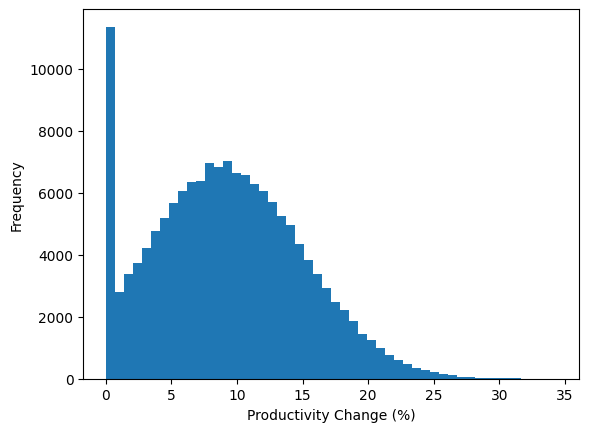

In [22]:
plt.hist(num_data_clean['productivity_change_percent'], bins=50)
plt.xlabel("Productivity Change (%)")
plt.ylabel("Frequency")
plt.show()

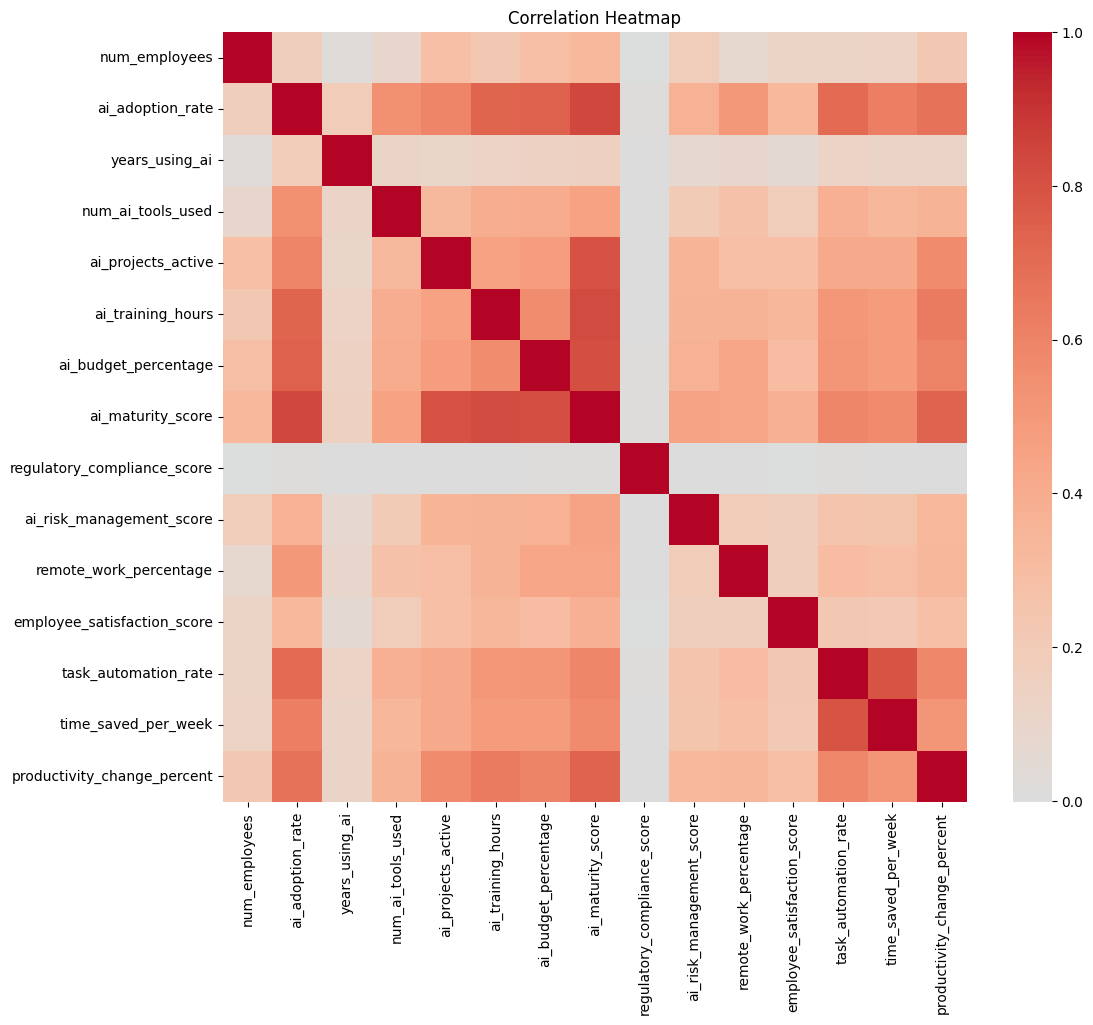

In [23]:
#check correlation between features
corr = num_data_clean.corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

In [24]:
#check correlation with the target for a overview
corr = num_data_clean.corr()
target_corr = corr['productivity_change_percent'].sort_values(ascending=False)
print(target_corr)

productivity_change_percent    1.000000
ai_maturity_score              0.737314
ai_adoption_rate               0.674973
ai_training_hours              0.633740
ai_budget_percentage           0.604105
task_automation_rate           0.582721
ai_projects_active             0.566833
time_saved_per_week            0.522476
num_ai_tools_used              0.364423
remote_work_percentage         0.340891
ai_risk_management_score       0.328775
employee_satisfaction_score    0.290436
num_employees                  0.225023
years_using_ai                 0.116494
regulatory_compliance_score    0.010039
Name: productivity_change_percent, dtype: float64


In [25]:
#Drop low relation features
#Prepare versions with various correlation cutoff for features to find the best performing prediction

thresholds = [0.20, 0.30, 0.50, 0.60]
num_data_corrcut = {}

for t in thresholds:
    selected = target_corr[abs(target_corr) >= t].index.tolist()
    num_data_corrcut[t] = num_data_clean[selected]
    
    print(f"\nThreshold {t}")
    print("Num col:", len(selected))
    print(selected)

#final data choosen
num_model_data = num_data_corrcut[0.5].copy()


Threshold 0.2
Num col: 13
['productivity_change_percent', 'ai_maturity_score', 'ai_adoption_rate', 'ai_training_hours', 'ai_budget_percentage', 'task_automation_rate', 'ai_projects_active', 'time_saved_per_week', 'num_ai_tools_used', 'remote_work_percentage', 'ai_risk_management_score', 'employee_satisfaction_score', 'num_employees']

Threshold 0.3
Num col: 11
['productivity_change_percent', 'ai_maturity_score', 'ai_adoption_rate', 'ai_training_hours', 'ai_budget_percentage', 'task_automation_rate', 'ai_projects_active', 'time_saved_per_week', 'num_ai_tools_used', 'remote_work_percentage', 'ai_risk_management_score']

Threshold 0.5
Num col: 8
['productivity_change_percent', 'ai_maturity_score', 'ai_adoption_rate', 'ai_training_hours', 'ai_budget_percentage', 'task_automation_rate', 'ai_projects_active', 'time_saved_per_week']

Threshold 0.6
Num col: 5
['productivity_change_percent', 'ai_maturity_score', 'ai_adoption_rate', 'ai_training_hours', 'ai_budget_percentage']


In [26]:
# Analyse categorical impact on target
for col in cat_data.columns:
    print()
    print(data.groupby(col)['productivity_change_percent'].mean().sort_values())


region
Africa            8.655562
South America     9.150045
Asia              9.195887
Europe            9.359549
North America     9.949178
Oceania          10.020748
Name: productivity_change_percent, dtype: float64

industry
Healthcare        8.595936
Consulting        8.654856
Education         8.785513
Agriculture       8.800457
Retail            8.985443
Manufacturing     9.052698
Logistics         9.131974
Finance           9.502793
Technology       11.166343
Name: productivity_change_percent, dtype: float64

company_size
Startup        8.201579
SME            8.916044
Enterprise    12.078983
Name: productivity_change_percent, dtype: float64

company_age_group
0-5 years      9.086779
6-15 years     9.215031
16-30 years    9.267946
30+ years      9.518579
Name: productivity_change_percent, dtype: float64

ai_adoption_stage
none        2.391995
pilot       6.165857
partial    12.026603
full       19.792315
Name: productivity_change_percent, dtype: float64

ai_use_case
Medical Di

In [27]:
#Drop low relevance features
cat_data_useful = cat_data.drop(['ai_use_case', 'data_privacy_level', 'region', 'company_size',
                              'company_age_group', 'ai_ethics_committee'], axis=1)

#Encode categorical features for training
ecd_model_data = pd.get_dummies(cat_data_useful, drop_first=True)

#Ver with cat data
model_with_catdata = pd.concat([num_model_data, ecd_model_data], axis=1)

print("Columns: ", len(model_with_catdata.columns))
model_with_catdata.columns

Columns:  19


Index(['productivity_change_percent', 'ai_maturity_score', 'ai_adoption_rate',
       'ai_training_hours', 'ai_budget_percentage', 'task_automation_rate',
       'ai_projects_active', 'time_saved_per_week', 'industry_Consulting',
       'industry_Education', 'industry_Finance', 'industry_Healthcare',
       'industry_Logistics', 'industry_Manufacturing', 'industry_Retail',
       'industry_Technology', 'ai_adoption_stage_none',
       'ai_adoption_stage_partial', 'ai_adoption_stage_pilot'],
      dtype='object')

In [28]:
#Split data for supervised model training 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#Choosen final data
final_data = model_with_catdata.copy()

# Keep original industry column separately for Technology masking later
industry_labels = data['industry'].reset_index(drop=True)

# features and target
X = final_data.drop('productivity_change_percent', axis=1)
y = final_data['productivity_change_percent']

# Train-test split, first split (train, temp)
X_train, X_temp, y_train, y_temp, industry_train, industry_temp = train_test_split(
    X, y, industry_labels, test_size=0.30, random_state=42
)

# second split (validation, test)
X_val, X_test, y_val, y_test, industry_val, industry_test = train_test_split(
    X_temp, y_temp, industry_temp, test_size=0.50, random_state=42
)

print("Train rows:", len(X_train))
print("Validation rows:", len(X_val))
print("Test rows:", len(X_test))
print("Technology rows in validation:", (industry_val == 'Technology').sum())
print("Technology rows in test:", (industry_test == 'Technology').sum())

Train rows: 105000
Validation rows: 22500
Test rows: 22500
Technology rows in validation: 3106
Technology rows in test: 3251


In [29]:
#Scale data for linear regrassion model
scaler = StandardScaler()

# fit only on training data
X_train_scaled = scaler.fit_transform(X_train)

# transform validation and test using same scaler
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(np.mean(X_train_scaled))
print(np.std(X_train_scaled))

8.561851991640487e-17
0.9999999999999999


## 4 Predictive Model

### Regression

Models compared:

- Multiple Linear Regression
- Polynomial Regression (Degree 2 and 3)
- Ridge Regression
- Lasso Regression
- Elastic Net Regression

In [31]:
#model training imports
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, RidgeCV, LassoCV, ElasticNetCV

In [32]:
#Define models

models = {
    "Linear": LinearRegression(),
    "Polynomial2": Pipeline([
        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),
    "Polynomial3": Pipeline([
        ("poly", PolynomialFeatures(degree=3, include_bias=False)),
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),
    "Ridge": RidgeCV(alphas=np.logspace(-3, 3, 20), cv=5),
    "Lasso": LassoCV(
        alphas=np.logspace(-3, 1, 20),
        cv=5,
        random_state=42,
        max_iter=10000
    ),
    "Elastic Net": ElasticNetCV(
        alphas=np.logspace(-3, 1, 20),
        l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9],
        cv=5,
        random_state=42,
        max_iter=10000
    )
}

In [33]:
#Train each of the model and evaluate on Technology validation data 

results = []

tech_val_mask = (industry_val == 'Technology').values

for name, model in models.items():
    if name in ["Linear", "Ridge", "Lasso", "Elastic Net"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_val_scaled)

    else:
        # use not scaled X because scaling is already in the pipeline
        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)

    # evaluate only on Technology rows
    y_val_tech = y_val.iloc[tech_val_mask]
    y_pred_tech = y_pred[tech_val_mask]

    results.append({
        "Model": name,
        "R2": r2_score(y_val_tech, y_pred_tech),
        "RMSE": np.sqrt(mean_squared_error(y_val_tech, y_pred_tech))
    })

val_results = pd.DataFrame(results).sort_values(by="R2", ascending=False).reset_index(drop=True)
val_results

,Model,R2,RMSE
0,Elastic Net,0.575182,3.710893
1,Lasso,0.575179,3.710906
2,Ridge,0.575165,3.710966
3,Linear,0.575124,3.711147
4,Polynomial2,0.574914,3.712063
5,Polynomial3,0.572963,3.720573


In [34]:
# Hyperparameter for tuned models
print("Best Ridge alpha:", models["Ridge"].alpha_)
print("Best Lasso alpha:", models["Lasso"].alpha_)
print("Best Elastic Net alpha:", models["Elastic Net"].alpha_)
print("Best Elastic Net l1_ratio:", models["Elastic Net"].l1_ratio_)

Best Ridge alpha: 112.88378916846884
Best Lasso alpha: 0.001
Best Elastic Net alpha: 0.001
Best Elastic Net l1_ratio: 0.7


In [35]:
# Display test result of the best model on Technology subset

tech_test_mask = (industry_test == 'Technology').values

y_test_pred = models["Lasso"].predict(X_test_scaled)

y_test_tech = y_test.iloc[tech_test_mask]
y_test_pred_tech = y_test_pred[tech_test_mask]

print("Technology Test R2:", r2_score(y_test_tech, y_test_pred_tech))
print("Technology Test RMSE:", np.sqrt(mean_squared_error(y_test_tech, y_test_pred_tech)))
print("Technology test rows:", tech_test_mask.sum())

Technology Test R2: 0.5824261568355709
Technology Test RMSE: 3.74513539955237
Technology test rows: 3251


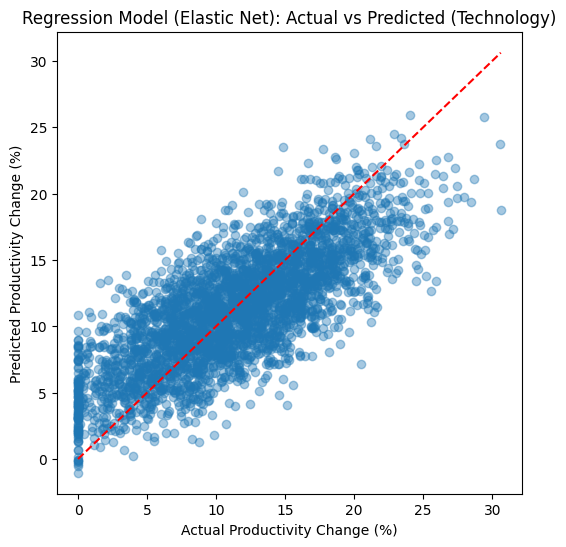

In [36]:
# Get predictions from best regression model (example: Elastic Net)
y_test_pred = models["Elastic Net"].predict(X_test_scaled)

# Mask Technology rows
tech_test_mask = (industry_test == 'Technology').values

y_test_tech = y_test.iloc[tech_test_mask]
y_pred_tech = y_test_pred[tech_test_mask]

plt.figure(figsize=(6,6))
plt.scatter(y_test_tech, y_pred_tech, alpha=0.4)

# perfect prediction line
plt.plot(
    [y_test_tech.min(), y_test_tech.max()],
    [y_test_tech.min(), y_test_tech.max()],
    'r--'
)

plt.xlabel("Actual Productivity Change (%)")
plt.ylabel("Predicted Productivity Change (%)")
plt.title("Regression Model (Elastic Net): Actual vs Predicted (Technology)")
plt.show()


## Deep Learning model

the full ~150,000 data points are used without any structuring.
evaluate separately on the Technology subset in the test set

The optimal architecture consists of three layers. 

Input layer accepts all preprocessed features, including scaled numerical variables and one-hot encoded categorical variables. 

Hidden layers includes 
- first hidden layer: 64 neurons with ReLU activation, dropout layer (rate = 0.2) to reduce overfitting
- second hidden layer: 32 neurons with ReLU activation.

output layer is a single neuron with linear activation to predict continuous target variables. 

In [148]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_absolute_error

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [150]:
#Ensure no future values or IDs are included in the predictive model that may cause data leakage
df = rawdata.copy()

target_col = 'productivity_change_percent'

# Drop obvious ID columns that should not be used
df = df.drop(['response_id', 'company_id', 'survey_source', 'data_collection_method'], axis=1)

#Drop redundancy in descriptive factors
df = df.drop(['country', 'company_age', 'ai_primary_tool', 'ai_investment_per_employee'], axis=1)

#Drop results of AI adoption and business performance variables, since they are not decisions
df = df.drop(['ai_failure_rate', 'reskilled_employees', 'revenue_growth_percent', 'annual_revenue_usd_millions',
                  'cost_reduction_percent', 'innovation_score', 'customer_satisfaction', 'jobs_displaced', 'jobs_created'], axis=1)

X = df.drop(columns=[target_col])
y = df[target_col]

In [172]:
#largely separate data into categorical and numerical
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

print("Numeric columns:", len(numeric_cols))
print(numeric_cols)
print("Categorical columns:", len(categorical_cols))
print(categorical_cols)

Numeric columns: 16
['survey_year', 'num_employees', 'company_founding_year', 'ai_adoption_rate', 'years_using_ai', 'num_ai_tools_used', 'ai_projects_active', 'ai_training_hours', 'ai_budget_percentage', 'ai_maturity_score', 'regulatory_compliance_score', 'ai_risk_management_score', 'remote_work_percentage', 'employee_satisfaction_score', 'task_automation_rate', 'time_saved_per_week']
Categorical columns: 9
['quarter', 'region', 'industry', 'company_size', 'company_age_group', 'ai_adoption_stage', 'ai_use_case', 'data_privacy_level', 'ai_ethics_committee']


In [154]:
#Split the data same way as regression model
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

print(X_train.shape, X_val.shape, X_test.shape)

(105000, 25) (22500, 25) (22500, 25)


In [156]:
#Prepare data for deep learning
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

print("Processed train shape:", X_train_processed.shape)

Processed train shape: (105000, 59)


In [157]:
# Build the model architechture
tf.random.set_seed(42)

model = keras.Sequential([
    layers.Input(shape=(X_train_processed.shape[1],)),

    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),

    layers.Dense(32, activation='relu'),

    layers.Dense(1)
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0005),
    loss='mse',
    metrics=['mae']
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                      │ (None, 64)                  │           3,840 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,953 (23.25 KB)

 Trainable params: 5,953 (23.25 KB)

 Non-trainable params: 0 (0.00 B)

In [160]:
#Utility function to observe training
class PrintEpochProgress(keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        print(
            f"Epoch {epoch+1:03d} | "
            f"loss={logs.get('loss'):.4f} | "
            f"val_loss={logs.get('val_loss'):.4f} | "
            f"mae={logs.get('mae'):.4f} | "
            f"val_mae={logs.get('val_mae'):.4f}"
        )

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [162]:
#Run model
history = model.fit(
    X_train_processed,
    y_train,
    validation_data=(X_val_processed, y_val),
    epochs=100,
    batch_size=256,
    verbose=0,
    callbacks=[PrintEpochProgress(), early_stop]
)

Epoch 001 | loss=27.5378 | val_loss=13.3735 | mae=3.9573 | val_mae=2.9352
Epoch 002 | loss=14.3164 | val_loss=13.2354 | mae=3.0343 | val_mae=2.9127
Epoch 003 | loss=14.1123 | val_loss=13.2063 | mae=3.0102 | val_mae=2.9093
Epoch 004 | loss=14.0423 | val_loss=13.2072 | mae=3.0022 | val_mae=2.9087
Epoch 005 | loss=13.9457 | val_loss=13.2046 | mae=2.9926 | val_mae=2.9087
Epoch 006 | loss=13.9041 | val_loss=13.2167 | mae=2.9879 | val_mae=2.9096
Epoch 007 | loss=13.8549 | val_loss=13.2204 | mae=2.9819 | val_mae=2.9100
Epoch 008 | loss=13.8506 | val_loss=13.2513 | mae=2.9830 | val_mae=2.9120
Epoch 009 | loss=13.7667 | val_loss=13.2531 | mae=2.9741 | val_mae=2.9128
Epoch 010 | loss=13.7309 | val_loss=13.3171 | mae=2.9707 | val_mae=2.9186


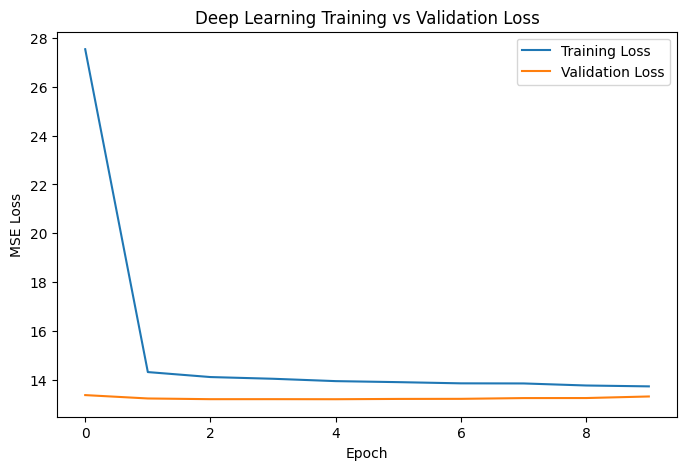

In [163]:
#Plot training to see if the training is successful
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Deep Learning Training vs Validation Loss')
plt.legend()
plt.show()

In [164]:
#predict test data
y_test_pred = model.predict(X_test_processed).flatten()

test_r2 = r2_score(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)

print("Full Test Set Performance")
print("R2:   ", test_r2)
print("RMSE: ", test_rmse)
print("MAE:  ", test_mae)

704/704 ━━━━━━━━━━━━━━━━━━━━ 0s 463us/step
Full Test Set Performance
R2:    0.5806228730927949
RMSE:  3.6738406432053092
MAE:   2.9463941643284692


In [165]:
#predict test data on Technology field
tech_mask = X_test['industry'] == 'Technology'

X_test_tech = X_test.loc[tech_mask]
y_test_tech = y_test.loc[tech_mask]

X_test_tech_processed = preprocessor.transform(X_test_tech)
X_test_tech_processed = X_test_tech_processed.toarray() if hasattr(X_test_tech_processed, "toarray") else X_test_tech_processed

y_test_tech_pred = model.predict(X_test_tech_processed).flatten()

tech_r2 = r2_score(y_test_tech, y_test_tech_pred)
tech_rmse = np.sqrt(mean_squared_error(y_test_tech, y_test_tech_pred))
tech_mae = mean_absolute_error(y_test_tech, y_test_tech_pred)

print("Technology Test Subset Performance")
print("Technology rows in test set:", len(X_test_tech))
print("R2:   ", tech_r2)
print("RMSE: ", tech_rmse)
print("MAE:  ", tech_mae)

102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 590us/step
Technology Test Subset Performance
Technology rows in test set: 3251
R2:    0.5812871471086483
RMSE:  3.750239695207984
MAE:   3.0143893470415075


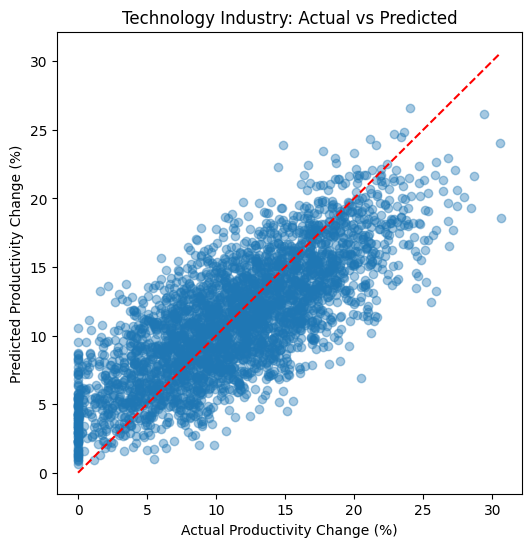

In [166]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test_tech, y_test_tech_pred, alpha=0.4)
plt.xlabel("Actual Productivity Change (%)")
plt.ylabel("Predicted Productivity Change (%)")
plt.title("Technology Industry: Actual vs Predicted")
plt.plot(
    [y_test_tech.min(), y_test_tech.max()],
    [y_test_tech.min(), y_test_tech.max()],
    'r--'
)
plt.show()